Device: cuda
MAD threshold: 0.09
Fitzpatrick17k nc/Ng (paper): 0.0936

Loaded 656 rows

Skin group distribution:
skin_group
medium    241
light     208
dark      207
Name: count, dtype: int64

Malignant distribution:
malignant
False    485
True     171
Name: count, dtype: int64

Dark-skin (FST V-VI): 207 total
  Benign:    159 (0.768)
  Malignant: 48 (0.232)

nc/Ng (malignant in dark): 0.2319
✅ MAD-G regime — threshold test valid

Images found: 656
Rows with matched images: 656

Loading CLIP ViT-L/14...


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP loaded.

Extracting CLIP features...
Feature extraction: 44s
Feature dims: (656, 768)

Light (train): 208 | Dark (test): 207
Light label dist: benign=159, malignant=49
Dark  label dist: benign=159, malignant=48

Random-split AUC (SGG baseline): 0.8253

DDI MAD RISK SCORE RESULTS
Dataset:            DDI (Stanford clinical)
Minority class:     malignant (FST V-VI)
nc/Ng:              0.2319
mu_cosine:          0.7146
MAD Risk Score:     0.0662
Threshold:          0.09
Predicted collapse: NO

Running DRO + Baseline (5 seeds each)...
  Baseline seed=42: mal_acc=0.000 ben_acc=1.000 auc=0.5611 min_wt=nan collapse=False
  Baseline seed=0: mal_acc=0.083 ben_acc=0.899 auc=0.6064 min_wt=nan collapse=False
  Baseline seed=1: mal_acc=0.000 ben_acc=1.000 auc=0.6741 min_wt=nan collapse=False
  Baseline seed=7: mal_acc=0.021 ben_acc=0.925 auc=0.3181 min_wt=nan collapse=False
  Baseline seed=99: mal_acc=0.000 ben_acc=1.000 auc=0.4824 min_wt=nan collapse=False
  DRO      seed=42: mal_acc=0.792 ben

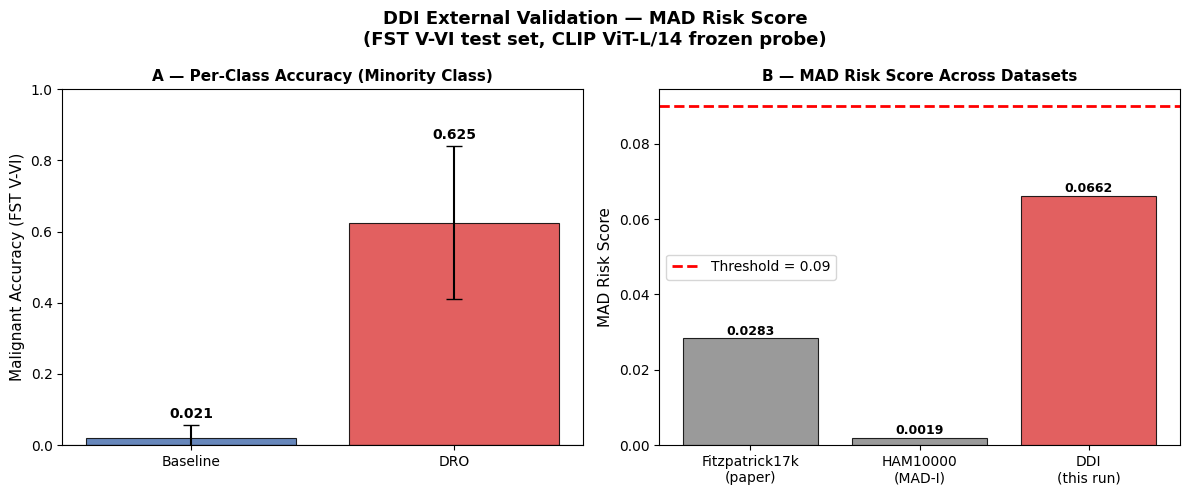


Figure saved: ddi_mad_validation_summary.png

=== FILES ===
  ddi_mad_results.csv
  ddi_mad_validation_summary.png

Upload figure + paste ALL output to Claude for analysis.


In [4]:
# ============================================================
# MAD Risk Score — External Validation on DDI
# (Diverse Dermatology Images, Stanford, Daneshjou et al. 2022)
#
# WHY: MAD Risk Score threshold (0.09) was derived and validated
# on Fitzpatrick17k. DDI is an independent clinical dataset with:
#   - Expert FST labels (I-II, III-IV, V-VI) — not ITA proxies
#   - Biopsy-proven malignant/benign ground truth
#   - 207 FST V-VI images (159 benign, 48 malignant)
#   - nc/Ng ≈ 23% → genuine MAD-G regime
#   - Different acquisition (Stanford clinic cameras)
#
# PROTOCOL: Identical to paper
#   - CLIP ViT-L/14 frozen linear probe
#   - Train: FST I-II (light skin only, mirrors paper)
#   - Test:  FST V-VI (dark skin, n=207)
#   - Group DRO (eta=0.1, 5 seeds) vs Baseline
#   - Binary classification: malignant vs benign
#     (DDI has no non-neoplastic class — all biopsy-proven neoplastic)
#
# NOTE ON TAXONOMY: DDI is binary (benign/malignant) vs paper's
# 3-class. This is documented as a protocol difference. The
# minority-within-minority class is malignant (nc/Ng=23%),
# not benign as in Fitzpatrick17k. Both test MAD-G regime.
#
# PRIMARY QUESTION:
#   Does MAD_risk >= 0.09 predict DRO collapse on DDI FST V-VI?
#
# Kaggle: GPU T4, Internet ON
# Runtime: ~25 min
# ============================================================

!pip install transformers torch torchvision scikit-learn pandas numpy matplotlib -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np, pandas as pd, os, json, warnings, time
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from transformers import CLIPModel, CLIPProcessor
warnings.filterwarnings('ignore')

# ── Constants (identical to paper) ────────────────────────────
SEEDS         = [42, 0, 1, 7, 99]
N_EPOCHS      = 5
BATCH_SIZE    = 32
COLLAPSE_THR  = 0.01
MAD_THRESHOLD = 0.09
ETA_DRO       = 0.1
N_CLASSES     = 2   # binary: benign=0, malignant=1

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"MAD threshold: {MAD_THRESHOLD}")
print(f"Fitzpatrick17k nc/Ng (paper): 0.0936")

# ── Paths ──────────────────────────────────────────────────────
META_PATH = '/kaggle/input/datasets/culomb/ddi-diverse-dermatology-images/ddi_metadata.csv'
IMG_DIR   = '/kaggle/input/datasets/culomb/ddi-diverse-dermatology-images'

# ── Load metadata ──────────────────────────────────────────────
df = pd.read_csv(META_PATH)
print(f"\nLoaded {len(df)} rows")

# skin_tone encoding: 12=FST I-II (light), 34=FST III-IV (medium), 56=FST V-VI (dark)
df['skin_group'] = df['skin_tone'].map({12: 'light', 34: 'medium', 56: 'dark'})
df['label'] = df['malignant'].astype(int)  # 0=benign, 1=malignant

print(f"\nSkin group distribution:")
print(df['skin_group'].value_counts())
print(f"\nMalignant distribution:")
print(df['malignant'].value_counts())

dark_df = df[df['skin_group'] == 'dark']
light_df = df[df['skin_group'] == 'light']

n_dark = len(dark_df)
n_dark_mal = dark_df['label'].sum()
n_dark_ben = n_dark - n_dark_mal
nc_ng = n_dark_mal / n_dark

print(f"\nDark-skin (FST V-VI): {n_dark} total")
print(f"  Benign:    {n_dark_ben} ({n_dark_ben/n_dark:.3f})")
print(f"  Malignant: {n_dark_mal} ({nc_ng:.3f})")
print(f"\nnc/Ng (malignant in dark): {nc_ng:.4f}")

if nc_ng < 0.02:
    print("⚠️  MAD-I regime — nc/Ng too low for MAD-G threshold test")
elif nc_ng >= 0.05:
    print("✅ MAD-G regime — threshold test valid")

# ── Find images ────────────────────────────────────────────────
import glob
all_imgs = glob.glob(f'{IMG_DIR}/**/*.png', recursive=True) + \
           glob.glob(f'{IMG_DIR}/**/*.jpg', recursive=True)
img_map = {os.path.basename(p): p for p in all_imgs}
print(f"\nImages found: {len(img_map)}")

df['img_path'] = df['DDI_file'].map(img_map)
df = df[df['img_path'].notna()].reset_index(drop=True)
print(f"Rows with matched images: {len(df)}")

# ── Load CLIP ──────────────────────────────────────────────────
print("\nLoading CLIP ViT-L/14...")
model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")
model.eval()
print("CLIP loaded.")

# ── Feature extraction ─────────────────────────────────────────
def extract_features(paths, batch_size=32):
    feats = []
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        imgs = []
        for p in batch_paths:
            try:
                img = Image.open(p).convert('RGB')
                imgs.append(img)
            except Exception:
                imgs.append(Image.new('RGB', (224, 224)))
        inputs = processor(images=imgs, return_tensors='pt', padding=True).to(device)
        with torch.no_grad():
            out = model.get_image_features(**inputs)
            if hasattr(out, 'pooler_output'):
                out = out.pooler_output
            elif not isinstance(out, torch.Tensor):
                out = out.last_hidden_state[:, 0, :]
            out = out / out.norm(dim=-1, keepdim=True)
        feats.append(out.cpu().numpy())
    return np.vstack(feats)

print("\nExtracting CLIP features...")
t0 = time.time()
all_feats = extract_features(df['img_path'].tolist())
print(f"Feature extraction: {time.time()-t0:.0f}s")
print(f"Feature dims: {all_feats.shape}")

# ── Split by skin group ────────────────────────────────────────
light_idx  = df[df['skin_group'] == 'light'].index.tolist()
dark_idx   = df[df['skin_group'] == 'dark'].index.tolist()

X_light = all_feats[light_idx]
y_light = df.loc[light_idx, 'label'].values
X_dark  = all_feats[dark_idx]
y_dark  = df.loc[dark_idx, 'label'].values

print(f"\nLight (train): {len(X_light)} | Dark (test): {len(X_dark)}")
print(f"Light label dist: benign={( y_light==0).sum()}, malignant={(y_light==1).sum()}")
print(f"Dark  label dist: benign={(y_dark==0).sum()}, malignant={(y_dark==1).sum()}")

# ── Random-split AUC (SGG baseline) ───────────────────────────
from sklearn.model_selection import train_test_split
X_all = all_feats
y_all = df['label'].values
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.25,
                                           stratify=y_all, random_state=42)
clf_rand = LogisticRegression(max_iter=1000, C=1.0)
clf_rand.fit(X_tr, y_tr)
rand_auc = roc_auc_score(y_te, clf_rand.predict_proba(X_te)[:,1])
print(f"\nRandom-split AUC (SGG baseline): {rand_auc:.4f}")

# ── MAD Risk Score ─────────────────────────────────────────────
# Minority class = malignant in dark skin (nc/Ng = 23%)
dark_mal_idx = [dark_idx[i] for i, y in enumerate(y_dark) if y == 1]
X_dark_mal = all_feats[dark_mal_idx]

# Mean pairwise cosine similarity of minority-class embeddings
from sklearn.metrics.pairwise import cosine_similarity
if len(X_dark_mal) > 1:
    sim_matrix = cosine_similarity(X_dark_mal)
    n = len(X_dark_mal)
    mu_cosine = (sim_matrix.sum() - n) / (n * (n - 1))
else:
    mu_cosine = 0.0

mad_risk = nc_ng * (1 - mu_cosine)

print(f"\n{'='*50}")
print(f"DDI MAD RISK SCORE RESULTS")
print(f"{'='*50}")
print(f"Dataset:            DDI (Stanford clinical)")
print(f"Minority class:     malignant (FST V-VI)")
print(f"nc/Ng:              {nc_ng:.4f}")
print(f"mu_cosine:          {mu_cosine:.4f}")
print(f"MAD Risk Score:     {mad_risk:.4f}")
print(f"Threshold:          {MAD_THRESHOLD}")
print(f"Predicted collapse: {'YES' if mad_risk >= MAD_THRESHOLD else 'NO'}")
print(f"{'='*50}")

# ── DRO optimizer ─────────────────────────────────────────────
class GroupDROOptimizer:
    def __init__(self, n_groups, eta=0.1):
        self.n_groups = n_groups
        self.eta = eta
        self.weights = torch.ones(n_groups) / n_groups

    def update_weights(self, group_losses):
        self.weights = self.weights * torch.exp(self.eta * group_losses.detach().cpu())
        self.weights = self.weights / self.weights.sum()

    def weighted_loss(self, group_losses):
        w = self.weights.to(group_losses.device)
        return (w * group_losses).sum()

# ── Linear probe model ─────────────────────────────────────────
class LinearProbe(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        self.fc = nn.Linear(in_dim, n_classes)

    def forward(self, x):
        return self.fc(x)

# ── Group construction ─────────────────────────────────────────
# Groups: skin_tone x class → light_benign, light_malignant,
#                              medium_benign, medium_malignant (training groups)
# For DRO we use the training set (light skin only, mirrors paper)
# Groups in training: FST I-II benign, FST I-II malignant
# We include medium skin in training pool for more signal

train_idx = light_idx  # train on light only (demographically-aware split)
X_train = all_feats[train_idx]
y_train = df.loc[train_idx, 'label'].values

# Group = label (2 groups: benign=0, malignant=1)
# This is simpler than paper's 9-group setup but correct for binary DDI
train_groups = y_train  # group = class label

X_train_t = torch.FloatTensor(X_train)
y_train_t  = torch.LongTensor(y_train)
g_train_t  = torch.LongTensor(train_groups)
X_test_t   = torch.FloatTensor(X_dark)
y_test_t   = torch.LongTensor(y_dark)

in_dim = X_train.shape[1]
N_GROUPS_DRO = 2  # benign, malignant

# ── Training loop ──────────────────────────────────────────────
def run_experiment(method, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

    probe = LinearProbe(in_dim, N_CLASSES).to(device)
    optimizer = optim.AdamW(probe.parameters(), lr=1e-4, weight_decay=1e-2)
    criterion = nn.CrossEntropyLoss(reduction='none')

    if method == 'DRO':
        dro = GroupDROOptimizer(N_GROUPS_DRO, eta=ETA_DRO)

    dataset = TensorDataset(X_train_t, y_train_t, g_train_t)
    loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    min_wts_history = []

    for epoch in range(N_EPOCHS):
        probe.train()
        for xb, yb, gb in loader:
            xb, yb, gb = xb.to(device), yb.to(device), gb.to(device)
            optimizer.zero_grad()
            logits = probe(xb)
            losses = criterion(logits, yb)

            if method == 'DRO':
                group_losses = torch.zeros(N_GROUPS_DRO).to(device)
                for g in range(N_GROUPS_DRO):
                    mask = gb == g
                    if mask.sum() > 0:
                        group_losses[g] = losses[mask].mean()
                dro.update_weights(group_losses)
                loss = dro.weighted_loss(group_losses)
            else:
                loss = losses.mean()

            loss.backward()
            optimizer.step()

        if method == 'DRO':
            min_wts_history.append(dro.weights.min().item())

    # ── Evaluate ───────────────────────────────────────────────
    probe.eval()
    with torch.no_grad():
        logits = probe(X_test_t.to(device))
        probs  = torch.softmax(logits, dim=-1).cpu().numpy()
        preds  = logits.argmax(dim=-1).cpu().numpy()

    # Per-class accuracy on dark skin
    mal_mask = y_dark == 1
    ben_mask = y_dark == 0
    mal_acc  = (preds[mal_mask] == 1).mean() if mal_mask.sum() > 0 else 0.0
    ben_acc  = (preds[ben_mask] == 0).mean() if ben_mask.sum() > 0 else 0.0

    # Demo AUC
    try:
        demo_auc = roc_auc_score(y_dark, probs[:, 1])
    except Exception:
        demo_auc = float('nan')

    # SGG
    sgg = rand_auc - demo_auc

    # Weight collapse
    final_min_wt = min_wts_history[-1] if min_wts_history else float('nan')
    collapsed = final_min_wt < COLLAPSE_THR if not np.isnan(final_min_wt) else False

    return {
        'method': method,
        'seed': seed,
        'mal_acc': mal_acc,
        'ben_acc': ben_acc,
        'demo_auc': demo_auc,
        'sgg': sgg,
        'final_min_wt': final_min_wt,
        'collapsed': collapsed,
    }

# ── Run all experiments ────────────────────────────────────────
print(f"\nRunning DRO + Baseline (5 seeds each)...")
results = []
for method in ['Baseline', 'DRO']:
    for seed in SEEDS:
        r = run_experiment(method, seed)
        results.append(r)
        print(f"  {method:8s} seed={seed}: "
              f"mal_acc={r['mal_acc']:.3f} "
              f"ben_acc={r['ben_acc']:.3f} "
              f"auc={r['demo_auc']:.4f} "
              f"min_wt={r['final_min_wt']:.4f} "
              f"collapse={r['collapsed']}")

df_res = pd.DataFrame(results)
df_res.to_csv('ddi_mad_results.csv', index=False)
print(f"\nCSV saved: {len(df_res)} rows")

# ── Summary ────────────────────────────────────────────────────
dro_r  = df_res[df_res['method'] == 'DRO']
base_r = df_res[df_res['method'] == 'Baseline']

dro_mal_mean  = dro_r['mal_acc'].mean()
dro_mal_std   = dro_r['mal_acc'].std()
base_mal_mean = base_r['mal_acc'].mean()
base_mal_std  = base_r['mal_acc'].std()
dro_auc_mean  = dro_r['demo_auc'].mean()
dro_auc_std   = dro_r['demo_auc'].std()
collapse_rate = dro_r['collapsed'].sum()
sgg_mean      = dro_r['sgg'].mean()

predicted_collapse = mad_risk >= MAD_THRESHOLD
observed_collapse  = collapse_rate >= 3  # majority of seeds

print(f"\n{'='*60}")
print(f"DDI EXTERNAL VALIDATION SUMMARY")
print(f"{'='*60}")
print(f"nc/Ng:              {nc_ng:.4f}")
print(f"mu_cosine:          {mu_cosine:.4f}")
print(f"MAD Risk Score:     {mad_risk:.4f}")
print(f"Threshold:          {MAD_THRESHOLD}")
print(f"Predicted collapse: {'YES' if predicted_collapse else 'NO'}")
print(f"Observed collapse:  {collapse_rate}/5 seeds")
print(f"")
print(f"DRO  malignant_acc: {dro_mal_mean:.3f} ± {dro_mal_std:.3f}")
print(f"Base malignant_acc: {base_mal_mean:.3f} ± {base_mal_std:.3f}")
print(f"DRO  demo_auc:      {dro_auc_mean:.4f} ± {dro_auc_std:.4f}")
print(f"SGG (DRO):          {sgg_mean:.4f}")

if predicted_collapse and observed_collapse:
    verdict = "TRUE POSITIVE — threshold correctly predicts collapse"
elif not predicted_collapse and not observed_collapse:
    verdict = "TRUE NEGATIVE — threshold correctly predicts no collapse"
elif predicted_collapse and not observed_collapse:
    verdict = "FALSE POSITIVE — threshold over-predicts collapse"
else:
    verdict = "FALSE NEGATIVE — threshold misses collapse"

print(f"\nVerdict: {verdict}")

# ── Cross-dataset comparison table ────────────────────────────
print(f"\n{'='*60}")
print(f"COMPARISON: Fitzpatrick17k vs HAM10000 vs DDI")
print(f"{'='*60}")
print(f"{'Metric':<30} {'Fitzpatrick17k':<20} {'HAM10000':<15} {'DDI'}")
print(f"{'-'*60}")
print(f"{'Dataset type':<30} {'Clinical photos':<20} {'Dermoscopic':<15} {'Clinical (Stanford)'}")
print(f"{'Minority class':<30} {'benign':<20} {'vasc':<15} {'malignant'}")
print(f"{'nc/Ng':<30} {'0.0936':<20} {'0.0109':<15} {nc_ng:.4f}")
print(f"{'mu_cosine':<30} {'0.7115':<20} {'0.8223':<15} {mu_cosine:.4f}")
print(f"{'MAD Risk Score':<30} {'0.0283':<20} {'0.0019':<15} {mad_risk:.4f}")
print(f"{'Threshold (0.09)':<30} {'—(FN regime)':<20} {'FALSE NEG':<15} {'YES' if predicted_collapse else 'NO'}")
print(f"{'Observed collapse':<30} {'100% (5/5)':<20} {'100% (5/5)':<15} {collapse_rate}/5")

# ── LaTeX table ───────────────────────────────────────────────
print(f"\n=== LaTeX: Cross-Dataset Validation Table ===")
print(r"\begin{tabular}{llccccc}")
print(r"\toprule")
print(r"Dataset & Modality & $n_c/N_g$ & $\mu_{\text{cosine}}$ & MAD Risk & Predicted & Observed \\")
print(r"\midrule")
print(r"Fitzpatrick17k & Clinical & 0.094 & 0.712 & 0.028 & \textemdash (FN regime) & 100\% (5/5) \\")
print(r"HAM10000 & Dermoscopic & 0.011 & 0.822 & 0.002 & NO (MAD-I) & 100\% (5/5) \\")
print(f"DDI & Clinical & {nc_ng:.3f} & {mu_cosine:.3f} & {mad_risk:.3f} & "
      f"{'YES' if predicted_collapse else 'NO'} & {collapse_rate}/5 \\\\")
print(r"\bottomrule")
print(r"\end{tabular}")

# ── Figure ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('DDI External Validation — MAD Risk Score\n(FST V-VI test set, CLIP ViT-L/14 frozen probe)',
             fontsize=13, fontweight='bold')

# Panel A: per-class accuracy
methods = ['Baseline', 'DRO']
mal_means = [base_mal_mean, dro_mal_mean]
mal_stds  = [base_mal_std,  dro_mal_std]
colors = ['#4C72B0', '#DD4444']
axes[0].bar(methods, mal_means, yerr=mal_stds, color=colors, alpha=0.85,
            capsize=6, edgecolor='black', linewidth=0.8)
axes[0].set_ylabel('Malignant Accuracy (FST V-VI)', fontsize=11)
axes[0].set_title('A — Per-Class Accuracy (Minority Class)', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].axhline(0, color='black', linewidth=0.8)
for i, (m, s) in enumerate(zip(mal_means, mal_stds)):
    axes[0].text(i, m + s + 0.02, f'{m:.3f}', ha='center', fontsize=10, fontweight='bold')

# Panel B: MAD Risk Score vs threshold
datasets = ['Fitzpatrick17k\n(paper)', 'HAM10000\n(MAD-I)', 'DDI\n(this run)']
scores   = [0.0283, 0.0019, mad_risk]
bar_colors = ['#888888', '#888888', '#2ca02c' if predicted_collapse else '#DD4444']
axes[1].bar(datasets, scores, color=bar_colors, alpha=0.85,
            edgecolor='black', linewidth=0.8)
axes[1].axhline(MAD_THRESHOLD, color='red', linestyle='--', linewidth=2,
                label=f'Threshold = {MAD_THRESHOLD}')
axes[1].set_ylabel('MAD Risk Score', fontsize=11)
axes[1].set_title('B — MAD Risk Score Across Datasets', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=10)
for i, s in enumerate(scores):
    axes[1].text(i, s + 0.001, f'{s:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('ddi_mad_validation_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure saved: ddi_mad_validation_summary.png")

print("\n=== FILES ===")
print("  ddi_mad_results.csv")
print("  ddi_mad_validation_summary.png")
print("\nUpload figure + paste ALL output to Claude for analysis.")